In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as mt

In [18]:
df=pd.read_csv("nyc_housing_base.csv")
print(df.head())

   borough_x  block  lot  sale_price  zip_code borough_y  yearbuilt  lotarea  \
0          1    400   11      280000   10009.0        MN     1900.0   2404.0   
1          1    402   36     2000000   10009.0        MN     1900.0   1919.0   
2          1    402   60     3400000   10009.0        MN     1920.0   2150.0   
3          1    404   42     4000000   10009.0        MN     1855.0   2369.0   
4          1    372   55      655000   10009.0        MN     1920.0   5298.0   

   bldgarea  resarea  comarea  unitsres  unitstotal  numfloors   latitude  \
0    6875.0   6875.0      0.0      18.0        18.0        5.0  40.724415   
1    7810.0   6810.0   1000.0       8.0        10.0        5.0  40.724975   
2    6152.0   5352.0    800.0       8.0         9.0        5.0  40.725346   
3    6990.0   6990.0      0.0      10.0        10.0        5.0  40.727398   
4   17990.0  17990.0      0.0      20.0        20.0        5.0  40.720621   

   longitude  landuse bldgclass  building_age  
0 -73.98

In [3]:
print("DATASET INFORMATION:\n")
print(df.info())
print("STATISTICAL SUMMARY OF THE DATASET:\n")
print(df.describe())

DATASET INFORMATION:

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 34439 entries, 0 to 34438
Data columns (total 19 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   borough_x     34439 non-null  int64  
 1   block         34439 non-null  int64  
 2   lot           34439 non-null  int64  
 3   sale_price    34439 non-null  int64  
 4   zip_code      34423 non-null  float64
 5   borough_y     34439 non-null  object 
 6   yearbuilt     34439 non-null  float64
 7   lotarea       34439 non-null  float64
 8   bldgarea      34439 non-null  float64
 9   resarea       34251 non-null  float64
 10  comarea       34251 non-null  float64
 11  unitsres      34439 non-null  float64
 12  unitstotal    34439 non-null  float64
 13  numfloors     34396 non-null  float64
 14  latitude      34433 non-null  float64
 15  longitude     34433 non-null  float64
 16  landuse       34436 non-null  float64
 17  bldgclass     34439 non-null  object 
 18  buil

In [4]:
print("\nNumber of missing values in each column:\n")
print(df.isnull().sum())


Number of missing values in each column:

borough_x         0
block             0
lot               0
sale_price        0
zip_code         16
borough_y         0
yearbuilt         0
lotarea           0
bldgarea          0
resarea         188
comarea         188
unitsres          0
unitstotal        0
numfloors        43
latitude          6
longitude         6
landuse           3
bldgclass         0
building_age      0
dtype: int64


In [5]:
print("\nNumber of duplicate rows:")
print(df.duplicated().sum())


Number of duplicate rows:
1003


In [6]:
#Data Preprocessing
df2=df.copy()
df2 = df2.drop_duplicates()
df2=df2.fillna(df2.mean(numeric_only=True))
print("\nDATASET AFTER PREPROCESSING:\n")
print(df2.head())


DATASET AFTER PREPROCESSING:

   borough_x  block  lot  sale_price  zip_code borough_y  yearbuilt  lotarea  \
0          1    400   11      280000   10009.0        MN     1900.0   2404.0   
1          1    402   36     2000000   10009.0        MN     1900.0   1919.0   
2          1    402   60     3400000   10009.0        MN     1920.0   2150.0   
3          1    404   42     4000000   10009.0        MN     1855.0   2369.0   
4          1    372   55      655000   10009.0        MN     1920.0   5298.0   

   bldgarea  resarea  comarea  unitsres  unitstotal  numfloors   latitude  \
0    6875.0   6875.0      0.0      18.0        18.0        5.0  40.724415   
1    7810.0   6810.0   1000.0       8.0        10.0        5.0  40.724975   
2    6152.0   5352.0    800.0       8.0         9.0        5.0  40.725346   
3    6990.0   6990.0      0.0      10.0        10.0        5.0  40.727398   
4   17990.0  17990.0      0.0      20.0        20.0        5.0  40.720621   

   longitude  landuse bld

In [7]:
corr_matrix = df2.corr(numeric_only=True)
print("CORRELATION WITH SALE PRICE\n")
print(corr_matrix["sale_price"].sort_values(ascending=False))


CORRELATION WITH SALE PRICE

sale_price      1.000000
building_age    0.132110
landuse         0.119960
latitude        0.009635
numfloors      -0.017482
comarea        -0.022298
lotarea        -0.040852
lot            -0.048628
bldgarea       -0.074661
resarea        -0.087375
zip_code       -0.088606
unitstotal     -0.114162
unitsres       -0.115728
longitude      -0.116753
yearbuilt      -0.132110
borough_x      -0.196035
block          -0.202393
Name: sale_price, dtype: float64


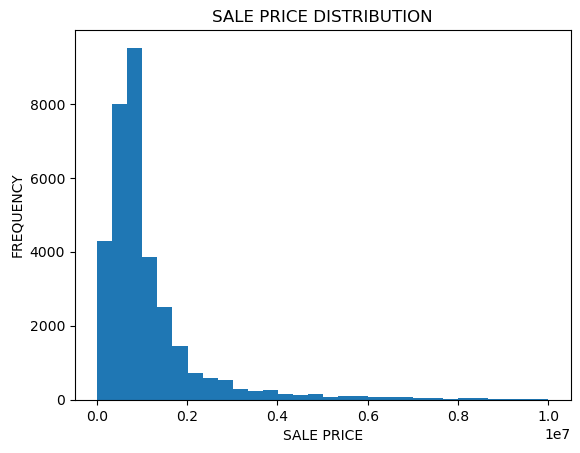

In [8]:
#Data visualization
mt.figure()
mt.hist(df2["sale_price"], bins=30)
mt.title("SALE PRICE DISTRIBUTION")
mt.xlabel("SALE PRICE")
mt.ylabel("FREQUENCY")
mt.show()

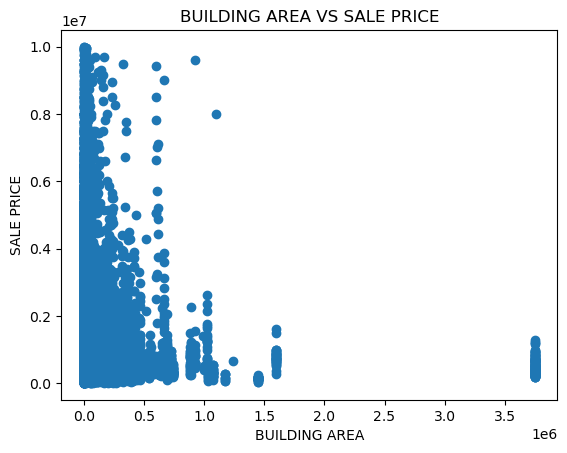

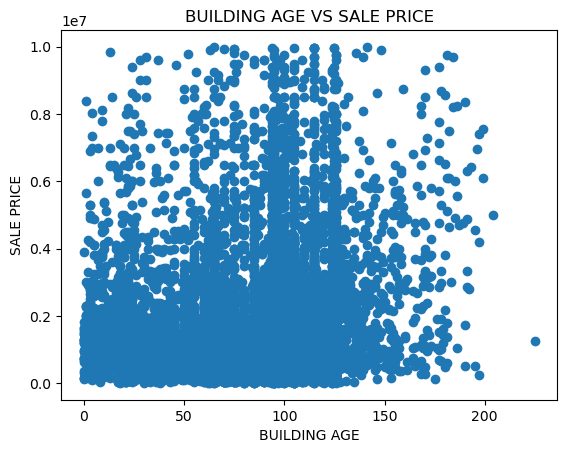

In [19]:
# SCATTER PLOTS
mt.figure()
mt.scatter(df2["bldgarea"], df2["sale_price"])
mt.xlabel("BUILDING AREA")
mt.ylabel("SALE PRICE")
mt.title("BUILDING AREA VS SALE PRICE")
mt.show()


mt.figure()
mt.scatter(df2["building_age"], df2["sale_price"])
mt.xlabel("BUILDING AGE")
mt.ylabel("SALE PRICE")
mt.title("BUILDING AGE VS SALE PRICE")
mt.show()

In [9]:
# Selected features based on correlation and domain reasoning
features = ["building_age", "landuse", "bldgarea", "resarea"]

X = df2[features].values
y = df2["sale_price"].values

In [10]:
ones = np.ones((X.shape[0],1))
X = np.hstack((ones, X))


In [11]:
#REGRESSION
def predict(X, theta):
    return np.dot(X, theta)


def compute_cost(X, y, theta):
    m = len(y)
    predictions = predict(X, theta)
    error = predictions - y
    cost = (1/(2*m)) * np.sum(error**2)
    return cost


def gradient_descent(X, y, theta, alpha, iterations):
    m = len(y)
    for i in range(iterations):
        predictions = predict(X, theta)
        error = predictions - y
        gradient = (1/m) * np.dot(X.T, error)
        theta = theta - alpha * gradient
    return theta

In [12]:
# TRAIN THE MODEL
theta = np.zeros(X.shape[1])

learning_rate = 0.00000000001
iterations = 1000

theta = gradient_descent(X, y, theta, learning_rate, iterations)

print("MODEL PARAMETERS (THETA VALUES)\n")
print(theta)

MODEL PARAMETERS (THETA VALUES)

[ 0.01097408  0.97703631  0.02262932 -3.07507949  4.83329252]


In [13]:
#Predictions
predicted_prices = predict(X, theta)

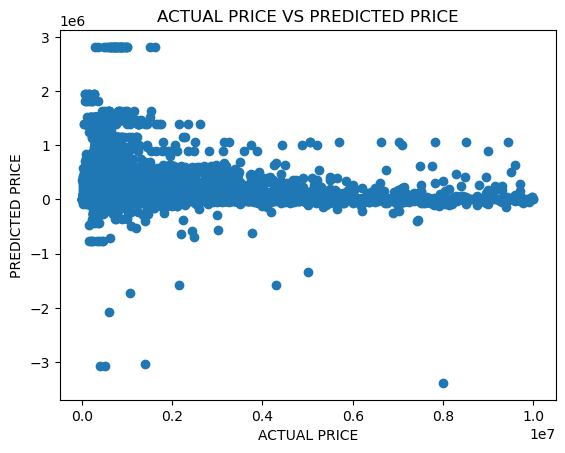

In [14]:
#VISUALIZE MODEL PERFORMANCE
mt.figure()
mt.scatter(y, predicted_prices)
mt.xlabel("ACTUAL PRICE")
mt.ylabel("PREDICTED PRICE")
mt.title("ACTUAL PRICE VS PREDICTED PRICE")
mt.show()


In [15]:
final_cost = compute_cost(X, y, theta)

print("FINAL COST OF MODEL:", final_cost)

FINAL COST OF MODEL: 1401191125800.6533
